Information:

- Course: EE658/758 Machine Learning in Engineering
- Assignment #2: Applying Linear Regression
- Student Name: Noah Pham
- BlazerID: tpham6


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [2]:
def add_bias(X: np.ndarray) -> np.ndarray:
    n_samples = X.shape[0]
    bias = np.ones((n_samples, 1))
    return np.hstack((bias, X))


def evaluate_regression(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    return {"mae": mae, "mse": mse}

## 1. Data Preprocessing


In [3]:
df = pd.read_csv("insurance.csv")
print("The number of rows with any missing values:", df.isnull().any(axis=1).sum())

The number of rows with any missing values: 17


In [4]:
df.dropna(inplace=True)
scaler = MinMaxScaler()
encoder = LabelEncoder()
for column in ["Gender", "Smoker", "Region"]:
    df[column] = encoder.fit_transform(df[column])

df.head()

,Age,Gender,BMI,Children,Smoker,Region,Expenses
0,19,0,27.9,0,1,3,16884.92
1,18,1,33.8,1,0,2,1725.55
2,28,1,33.0,3,0,2,4449.46
3,33,1,22.7,0,0,1,21984.47
4,32,1,28.9,0,0,1,3866.86


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 1321 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1321 non-null   int64  
 1   Gender    1321 non-null   int64  
 2   BMI       1321 non-null   float64
 3   Children  1321 non-null   int64  
 4   Smoker    1321 non-null   int64  
 5   Region    1321 non-null   int64  
 6   Expenses  1321 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 82.6 KB


## 2. Splitting the Data


In [6]:
y = df["Expenses"]
X = df.drop("Expenses", axis=1)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3. GD Implementation


In [9]:
class GradientDescent:
    def __init__(self, lr: float = 0.01, decay_rate: float = 0.01):
        self.lr = lr
        self.n_iters = 1000
        self.decay_rate = decay_rate

    def fit(self, X: np.ndarray, y: np.ndarray):
        X_b = add_bias(X)
        n_samples, n_features = X_b.shape
        self.theta = np.zeros(n_features)
        self.losses = []

        for i in range(self.n_iters):
            y_pred = X_b.dot(self.theta)
            gradient = (1 / n_samples) * X_b.T.dot(y_pred - y)
            self.theta -= self.lr * gradient

            # Calculate and store the loss
            loss = np.mean((y_pred - y) ** 2)
            self.losses.append(loss)

            # Apply learning rate decay
            self.lr = self.lr * np.exp(-self.decay_rate * i)

    def plot_loss(self):
        plt.figure(figsize=(10, 6))
        plt.plot(range(len(self.losses)), self.losses, linewidth=2)
        plt.xlabel("Iterations", fontsize=12)
        plt.ylabel("MSE Loss", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.show()

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_b = add_bias(X)
        return X_b.dot(self.theta)


model = GradientDescent()
model.fit(X_train, y_train)

In [10]:
print("Coefficients:", model.theta[1:])
print("Intercept:", model.theta[0])

Coefficients: [858.62468237 808.38586759 645.095882   861.23236088 807.20961698
 751.66076324]
Intercept: 1519.7299383141997


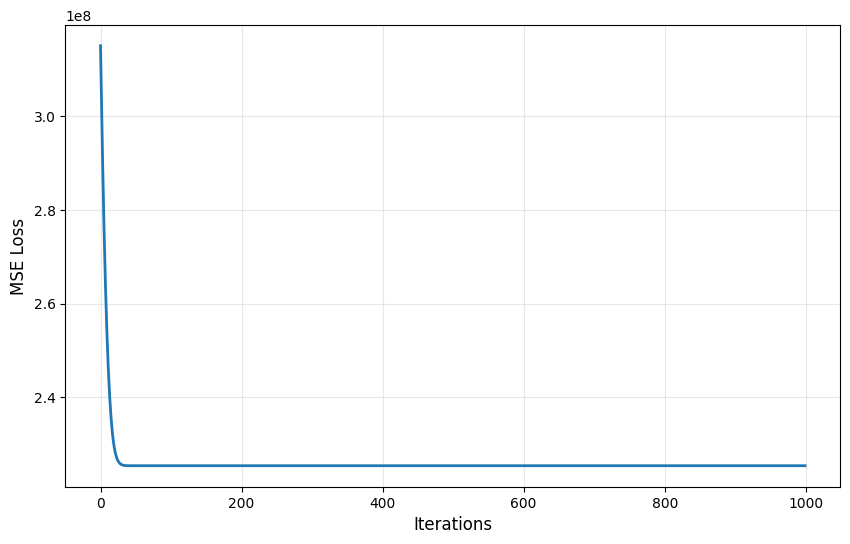

In [11]:
model.plot_loss()

## 4. Model Evaluation


In [12]:
gd_metrics = evaluate_regression(y_test, model.predict(X_test))

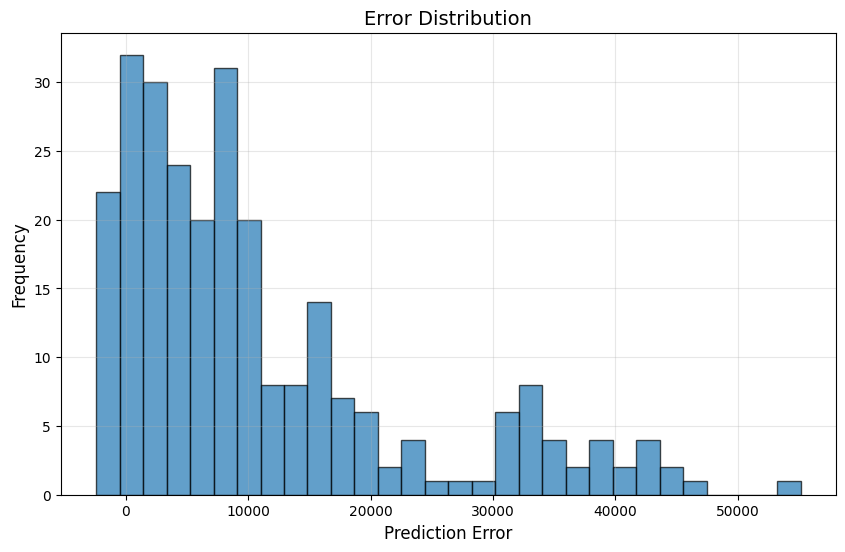

In [13]:
def plot_error_distribution(y_true: np.ndarray, y_pred: np.ndarray):
    errors = y_true - y_pred
    plt.figure(figsize=(10, 6))
    plt.hist(errors, bins=30, edgecolor="k", alpha=0.7)
    plt.xlabel("Prediction Error", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Error Distribution", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()


y_pred = model.predict(X_test)
plot_error_distribution(y_test, y_pred)

## 5. Using the learned coeﬃcients from your regression model


In [14]:
feature_names = list(X.columns)
theta = model.theta[1:]
coeffs = pd.Series(theta, index=feature_names)

pd.DataFrame(
    {
        "Feature": feature_names,
        "Coefficient": coeffs.values,
        "Sign": ["+" if coeffs[feat] > 0 else "-" for feat in feature_names],
    }
).head(10)

,Feature,Coefficient,Sign
0,Age,858.624682,+
1,Gender,808.385868,+
2,BMI,645.095882,+
3,Children,861.232361,+
4,Smoker,807.209617,+
5,Region,751.660763,+


All features in this model show a positive correlation with total expenses. This indicates that as the value of any given feature increases, the predicted expense increases accordingly.

- Relationship: The positive coefficients imply that higher feature values drive higher costs. For instance, age is a significant factor; as a person grows older, their associated expenses typically rise.

- Real-world Scenario: The model aligns well with practical expectations. A primary example is the smoker variable. In a real-world context, individuals who smoke incur higher daily costs due to the price of cigarettes, which is accurately reflected in the model’s upward trend.


## 6. Learning Rate Analysis


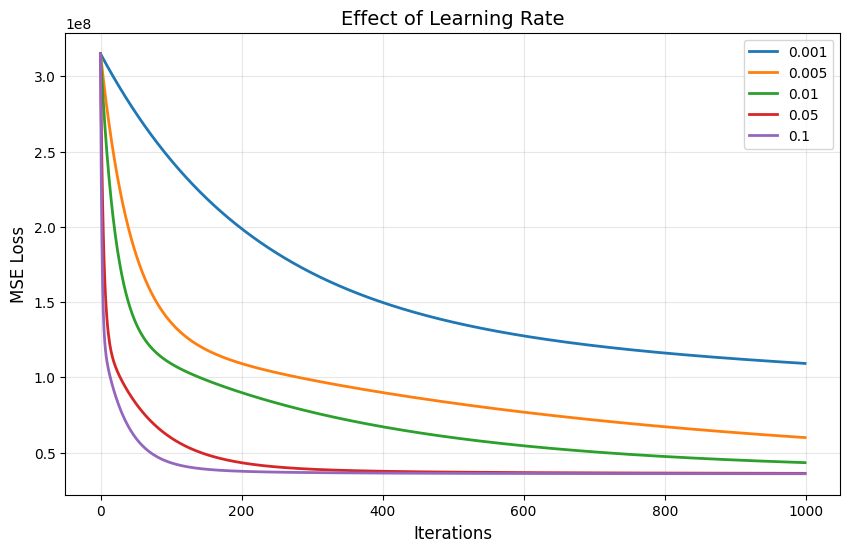

In [15]:
plt.figure(figsize=(10, 6))
for lr in [0.001, 0.005, 0.01, 0.05, 0.1]:
    gd = GradientDescent(lr=lr, decay_rate=0.0)
    gd.fit(X_train, y_train)
    plt.plot(gd.losses, label=lr, linewidth=2)

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.title("Effect of Learning Rate", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Scikit-learn Implementation


In [16]:
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_metrics = evaluate_regression(y_test, sk_model.predict(X_test))

## 8. Normal Equation Implementation


In [17]:
X_b = add_bias(X_train)
theta_ne = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train)

y_pred_ne = add_bias(X_test).dot(theta_ne)
ne_metrics = evaluate_regression(y_test, y_pred_ne)

## 9. Comparision


In [18]:
metrics = pd.DataFrame(
    {
        "Model": ["Gradient Descent", "Linear Regression", "Normal Equation"],
        "MAE": [gd_metrics["mae"], sk_metrics["mae"], ne_metrics["mae"]],
        "MSE": [gd_metrics["mse"], sk_metrics["mse"], ne_metrics["mse"]],
    }
)
metrics.head()

,Model,MAE,MSE
0,Gradient Descent,11132.862844,2.630720e+08
1,Linear Regression,4594.059451,4.310246e+07
2,Normal Equation,4594.059451,4.310246e+07
